STEP 0 — Setup, reproducibility, and dependencies

Purpose. This step establishes a reproducible analysis environment by importing required libraries, defining global constants (e.g., milliseconds‑to‑minutes conversion), and fixing the input/output locations used throughout the pipeline. Centralising configuration reduces the risk of inconsistent results caused by changes in file paths or parameters across notebook sessions. 

Key decisions. The analysis uses standard scientific Python tooling (pandas, NumPy, scikit‑learn, matplotlib) to ensure transparency and replicability. Timezone handling is fixed to Europe/London to maintain validity of “time‑of‑day” features and to respect UK daylight savings time. 

Outputs. None (setup stage).

In [17]:

import json
import warnings
from pathlib import Path
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dateutil import tz
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")

# ----------------------------
# File locations
# ----------------------------
INPUT_DIR = Path(
    r"C:\Users\399438\OneDrive - Lloyds Banking Group\PCA\Data Science Degree"
    r"\Module 5 - Data Science Professional Practice\Assessment"
    r"\Public Dataset\Inputs\extended"
)

OUTPUT_DIR = Path(
    r"C:\Users\399438\OneDrive - Lloyds Banking Group\PCA\Data Science Degree"
    r"\Module 5 - Data Science Professional Practice\Assessment"
    r"\Public Dataset\outputs"
)

CSV_FALLBACK = Path(
    r"C:\Users\399438\OneDrive - Lloyds Banking Group\PCA\Data Science Degree"
    r"\Module 5 - Data Science Professional Practice\Assessment"
    r"\Public Dataset\Inputs\artist_genres_kaggle.csv"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Time handling constants
# ----------------------------
LONDON_TZ = tz.gettz("Europe/London")
MS_TO_MIN = 1.0 / 60000.0


STEP 1 — Load and normalise Spotify Extended Streaming History (Audio)

Purpose. This step consolidates all Spotify Extended Streaming History (Audio) JSON files into a single event‑level dataset, then standardises timestamps and core metadata fields needed for later aggregation.

Key decisions.

- Timestamp conversion: Spotify timestamps are supplied in UTC and are converted to Europe/London local time. This supports valid interpretation of hourly and day‑of‑week listening rhythms, which are central to the day‑type clustering objective. 
- Music‑only filtering: Podcast/episode rows are removed using episode metadata fields. This improves construct validity by ensuring that “day types” reflect music listening behaviour rather than mixed media consumption.
- Duration normalisation: Listening time is converted from milliseconds to minutes to produce interpretable measures for daily aggregation.

Outputs. An analysis‑ready “plays” table containing one row per streaming event.



In [18]:

def is_music_row(row: pd.Series) -> bool:
    """
    Identify genuine music streams by excluding podcast / episode rows.
    """
    if str(row.get("spotify_episode_uri", "")).strip():
        return False
    if str(row.get("episode_name", "")).strip():
        return False
    if str(row.get("episode_show_name", "")).strip():
        return False
    return True


def load_audio_history(input_dir: Path) -> pd.DataFrame:
    """
    Load and combine Spotify Streaming_History_Audio JSON files,
    clean timestamps, and derive core listening metrics.
    """
    files = sorted(input_dir.glob("Streaming_History_Audio_*.json"))
    if not files:
        raise FileNotFoundError("No Streaming_History_Audio JSON files found")

    frames: List[pd.DataFrame] = []

    for file in files:
        with open(file, "r", encoding="utf-8") as fh:
            data = json.load(fh)
            df = pd.json_normalize(data)
            df["source_file"] = file.name
            frames.append(df)

    plays = pd.concat(frames, ignore_index=True)
 

# --- Filter to music only (robust to NaN / None) ---
    plays = plays[
        plays["spotify_episode_uri"].isna()
        & plays["episode_name"].isna()
        & plays["episode_show_name"].isna()
    ].copy()
    

    # --- Time handling ---
    plays["ts"] = pd.to_datetime(plays["ts"], utc=True, errors="coerce")
    plays["local_ts"] = plays["ts"].dt.tz_convert(LONDON_TZ)
    plays["local_date"] = plays["local_ts"].dt.date
    plays["hour"] = plays["local_ts"].dt.hour
    plays["dow"] = plays["local_ts"].dt.dayofweek

    # --- Filter to music only ---
    #plays = plays[plays.apply(is_music_row, axis=1)].copy()

    # --- Core metrics ---
    plays["min_played"] = plays["ms_played"].fillna(0) * MS_TO_MIN
    plays["artist_name"] = plays["master_metadata_album_artist_name"]
    plays["track_name"] = plays["master_metadata_track_name"]
    plays["track_uri"] = plays["spotify_track_uri"]

    # --- Track ID (used for CSV fallback joins) ---
    plays["track_id"] = (
        plays["track_uri"]
        .astype(str)
        .str.split(":")
        .str[-1]
    )

    return plays



 STEP 2 — Audio feature enrichment

 PURPOSE:
 Add musical attributes (tempo, energy, danceability, valence)
 to each track. The script attempts to use the Spotify API,
 but if unavailable (e.g. LBG restrictions), it falls back to
 the local Kaggle CSV file.


In [19]:

def enrich_audio_features(plays: pd.DataFrame) -> pd.DataFrame:
    """
    Attempt Spotify API enrichment; fall back to Kaggle CSV if unavailable.
    """
    try:
        import spotipy
        from spotipy.oauth2 import SpotifyClientCredentials

        sp = spotipy.Spotify(
            auth_manager=SpotifyClientCredentials()
        )

        uris = plays["track_uri"].dropna().unique().tolist()
        rows = []

        for i in range(0, len(uris), 50):
            batch = uris[i:i + 50]
            features = sp.audio_features(batch)

            for f in features:
                if f:
                    rows.append(f)

        audio_df = (
            pd.DataFrame(rows)
            .rename(columns={"uri": "track_uri"})
        )

        enriched = plays.merge(
            audio_df,
            on="track_uri",
            how="left"
        )
        enriched["audio_source"] = "spotify_api"
        return enriched

    except Exception as e:
        print("Spotify API unavailable – using CSV fallback")
        csv = pd.read_csv(CSV_FALLBACK)

        enriched = plays.merge(
            csv,
            on="track_id",
            how="left"
        )
        enriched["audio_source"] = "csv_fallback"
        return enriched


# ============================================================
# Data loading & enrichment
# ============================================================

plays = load_audio_history(INPUT_DIR)


In [20]:
plays.head()


,ts,platform,ms_played,conn_country,ip_addr,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,...,source_file,local_ts,local_date,hour,dow,min_played,artist_name,track_name,track_uri,track_id
0,2013-12-29 14:51:05+00:00,"iOS 7.0.4 (iPhone6,2)",175746,GB,94.175.33.251,Storm Passes Away,Jake Bugg,Shangri La,spotify:track:48OQok0LzyYm4gUTwtDinn,None,...,Streaming_History_Audio_2013-2019_0.json,2013-12-29 14:51:05+00:00,2013-12-29,14,6,2.929100,Jake Bugg,Storm Passes Away,spotify:track:48OQok0LzyYm4gUTwtDinn,48OQok0LzyYm4gUTwtDinn
1,2013-12-29 14:55:04+00:00,"iOS 7.0.4 (iPhone6,2)",238333,GB,94.175.33.251,A Song About Love,Jake Bugg,Shangri La,spotify:track:7BVhbXI57mzTe7qVMdqzCi,None,...,Streaming_History_Audio_2013-2019_0.json,2013-12-29 14:55:04+00:00,2013-12-29,14,6,3.972217,Jake Bugg,A Song About Love,spotify:track:7BVhbXI57mzTe7qVMdqzCi,7BVhbXI57mzTe7qVMdqzCi
2,2013-12-29 14:56:58+00:00,"iOS 7.0.4 (iPhone6,2)",54427,GB,94.175.33.251,Messed Up Kids,Jake Bugg,Shangri La,spotify:track:2ZJeRjU4MII0lc0MZYwVrJ,None,...,Streaming_History_Audio_2013-2019_0.json,2013-12-29 14:56:58+00:00,2013-12-29,14,6,0.907117,Jake Bugg,Messed Up Kids,spotify:track:2ZJeRjU4MII0lc0MZYwVrJ,2ZJeRjU4MII0lc0MZYwVrJ
3,2013-12-29 14:57:01+00:00,"iOS 7.0.4 (iPhone6,2)",3668,GB,94.175.33.251,"Blood, Tears & Gold",Hurts,Happiness - Deluxe Edition,spotify:track:3HdMv6Ss9TCPbEgrYxg6oi,None,...,Streaming_History_Audio_2013-2019_0.json,2013-12-29 14:57:01+00:00,2013-12-29,14,6,0.061133,Hurts,"Blood, Tears & Gold",spotify:track:3HdMv6Ss9TCPbEgrYxg6oi,3HdMv6Ss9TCPbEgrYxg6oi
4,2013-12-29 14:59:35+00:00,"iOS 7.0.4 (iPhone6,2)",153813,GB,94.175.33.251,Honey Bunny,Girls,"Father, Son, Holy Ghost",spotify:track:7Hwq7NMOdsRqsoBAclS40K,None,...,Streaming_History_Audio_2013-2019_0.json,2013-12-29 14:59:35+00:00,2013-12-29,14,6,2.563550,Girls,Honey Bunny,spotify:track:7Hwq7NMOdsRqsoBAclS40K,7Hwq7NMOdsRqsoBAclS40K


In [21]:
plays = enrich_audio_features(plays)

# Diagnostic for reporting
audio_coverage = plays["tempo"].notna().mean()
print(f"Audio feature coverage: {audio_coverage:.1%}")


Spotify API unavailable – using CSV fallback
Audio feature coverage: 27.5%


In [22]:

# Number of unique artists
num_unique_artists = plays['master_metadata_album_artist_name'].nunique()

print(f"Number of unique artists: {num_unique_artists}")


Number of unique artists: 10145



 STEP 3 — Exploratory Data Analysis (EDA)

Purpose. This step provides descriptive evidence about listening behaviour prior to modelling, including intensity, temporal rhythms, and dominant artists. The intent is to ensure data quality and to surface patterns that the clustering later aims to formalise. 

Typical outputs (saved to disk).
- Daily listening minutes over time
- Hour‑of‑day distribution (share of minutes)
- Day‑of‑week distribution (share of minutes)
- Device share (e.g., phone vs desktop) and context flags (shuffle/incognito/offline)
- Top artists by minutes
- These outputs are saved as PNG/CSV artefacts to support reporting and reproducibility.

In [23]:

EDA_DIR = OUTPUT_DIR / "eda"
EDA_DIR.mkdir(exist_ok=True)

# --- Daily minutes listened ---
daily_minutes = (
    plays.groupby("local_date")["min_played"].sum()
)

plt.figure(figsize=(12, 4))
daily_minutes.plot()
plt.title("Daily Music Listening Minutes Over Time")
plt.ylabel("Minutes")
plt.xlabel("Date")
plt.tight_layout()
plt.savefig(EDA_DIR / "daily_minutes.png")
plt.close()

# --- Day-of-week × hour heatmap ---
pivot = (
    plays.pivot_table(
        index="dow",
        columns="hour",
        values="min_played",
        aggfunc="sum",
        fill_value=0
    )
)

pivot = pivot / pivot.values.sum()

plt.figure(figsize=(14, 4))
sns.heatmap(pivot, cmap="Blues")
plt.title("Listening Distribution by Day of Week and Hour")
plt.ylabel("Day of Week (Mon = 0)")
plt.xlabel("Hour of Day")
plt.tight_layout()
plt.savefig(EDA_DIR / "dow_hour_heatmap.png")
plt.close()

# --- Audio feature distributions ---
audio_cols = ["danceability", "energy", "valence", "tempo"]

for col in audio_cols:
    plt.figure(figsize=(6, 3))
    plays[col].dropna().hist(bins=40)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.savefig(EDA_DIR / f"dist_{col}.png")
    plt.close()


outputs/eda/eda_daily_minutes.png

outputs/eda/eda_hour_share.png

outputs/eda/eda_dow_share.png

outputs/eda/eda_top_artists.png

 STEP 4 — Feature engineering (day level)

 PURPOSE:
 Build a rich day-level representation combining:
 - temporal listening patterns
 - device/context behaviour
 - artist composition and latent themes
 - musical attributes (audio features)


In [24]:
def build_temporal_block(plays):
    temp = (
        plays.groupby(["local_date", "hour"])["min_played"]
        .sum()
        .unstack(fill_value=0)
    )
    temp = temp.div(temp.sum(axis=1), axis=0).fillna(0)
    temp.columns = [f"hour_{h:02d}" for h in temp.columns]
    return temp


def build_audio_block(plays):
    audio = (
        plays.groupby("local_date")
        .agg({
            "danceability": ["mean", "std"],    
            "energy": ["mean", "std"],
            "valence": ["mean", "std"],
            "tempo": ["mean", "std"]
        })
        .fillna(0)
    )

    # FLATTEN MultiIndex columns
    audio.columns = [
        f"{feat}_{stat}" for feat, stat in audio.columns
    ]

    return audio


def build_daily_artist_minutes(plays):
    return (
        plays.groupby(["local_date", "artist_name"])["min_played"]
        .sum()
        .unstack(fill_value=0)
    )


def build_artist_svd(daily_artist_minutes, n_components=30):
    corpus = [
        " ".join(row[row > 0].index)
        for _, row in daily_artist_minutes.iterrows()
    ]
    tfidf = TfidfVectorizer(token_pattern=r"[^ ]+")
    M = tfidf.fit_transform(corpus)
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    Z = svd.fit_transform(M)
    return pd.DataFrame(
        Z,
        index=daily_artist_minutes.index,
        columns=[f"artist_svd_{i:02d}" for i in range(n_components)]
    )


temporal = build_temporal_block(plays)
audio = build_audio_block(plays)
daily_artist_minutes = build_daily_artist_minutes(plays)
artist_svd = build_artist_svd(daily_artist_minutes)


In [10]:
temporal.head()


,hour_00,hour_01,hour_02,hour_03,hour_04,hour_05,hour_06,hour_07,hour_08,hour_09,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
local_date,,,,,,,,,,,,,,,,,,,,,
2013-12-29,0.00000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.073655,0.415259,0.420378,0.090707,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2013-12-30,0.00000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.152965,0.426081,0.400677,0.020276
2013-12-31,0.00000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.228815,0.353241,0.345538,0.072406,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2014-02-05,0.00000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.074734,0.176494,0.193735,0.185075,0.176056,0.193906
2014-02-06,0.23792,0.154225,0.368352,0.147546,0.0,0.0,0.0,0.0,0.0,0.0,...,0.091957,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [11]:
audio


,danceability_mean,danceability_std,energy_mean,energy_std,valence_mean,valence_std,tempo_mean,tempo_std
local_date,,,,,,,,
2013-12-29,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2013-12-30,0.561000,0.231931,0.395000,0.265872,0.515000,0.349311,125.633000,64.557435
2013-12-31,0.766667,0.091221,0.894000,0.019053,0.828333,0.016743,122.934000,5.184028
2014-02-05,0.484000,0.000000,0.368000,0.000000,0.142000,0.000000,92.923000,0.000000
2014-02-06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...
2026-02-06,0.532883,0.255312,0.541833,0.271657,0.443617,0.240190,110.386500,27.601060
2026-02-07,0.628000,0.000000,0.882000,0.000000,0.853000,0.000000,95.083000,0.000000
2026-02-08,0.495154,0.122929,0.747692,0.181224,0.717985,0.215005,109.016538,22.432335


 STEP 5 — Assemble feature matrix

 PURPOSE:
 Combine all feature blocks into a single day-level matrix
 suitable for clustering.



In [25]:

X = temporal.join(audio, how="left").join(artist_svd, how="left").fillna(0)


 STEP 6 — K-means clustering

 PURPOSE:
 Identify natural "day types" using un


In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

best_k, best_score = None, -1
for k in range(3, 12):
    km = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    if score > best_score:
        best_k, best_score = k, score

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=50)
X["cluster"] = kmeans.fit_predict(X_scaled)

from types import SimpleNamespace

# Make sure we compute centroids for feature columns only (exclude cluster)
X_features = X.drop(columns=["cluster"], errors="ignore")

# Centroids are in scaled space; convert back to original feature units
centroid_df = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=X_features.columns,
    index=[f"Cluster {i}" for i in range(kmeans.n_clusters)]
)

# Create a lightweight 'result' object with the attributes STEP 9 expects
result = SimpleNamespace(
    model=kmeans,
    labels=X["cluster"].to_numpy(),
    centroid_df=centroid_df,
    features_scaled=X_scaled
)

X.to_csv(OUTPUT_DIR / "day_features_with_clusters.csv")

visual the silhouette scores

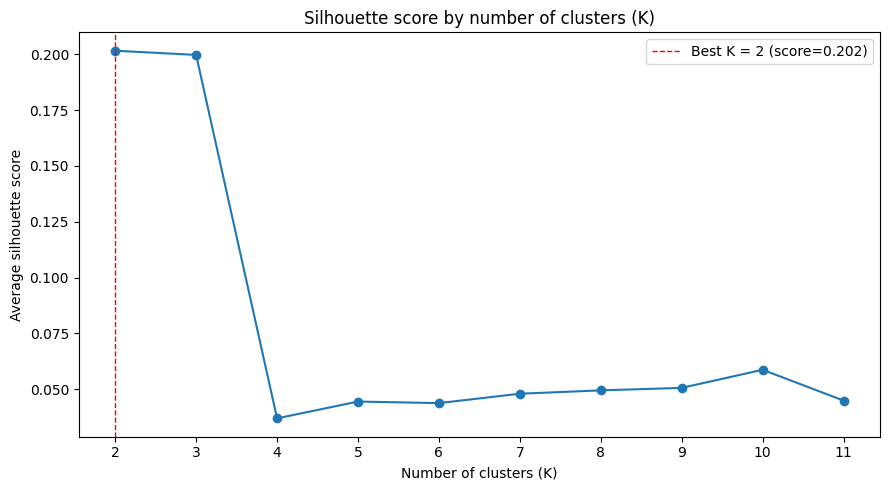

Best K by silhouette: 2 with score=0.2016


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# --- your existing scaling ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- compute silhouette scores across K ---
k_values = list(range(2, 12))  # silhouette defined for k>=2; match your range if you prefer 3..11
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

best_k = k_values[int(np.argmax(sil_scores))]
best_score = float(np.max(sil_scores))

# --- plot ---
plt.figure(figsize=(9, 5))
plt.plot(k_values, sil_scores, marker="o")
plt.xticks(k_values)
plt.xlabel("Number of clusters (K)")
plt.ylabel("Average silhouette score")
plt.title("Silhouette score by number of clusters (K)")
plt.axvline(best_k, color="red", linestyle="--", linewidth=1, label=f"Best K = {best_k} (score={best_score:.3f})")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best K by silhouette: {best_k} with score={best_score:.4f}")


 STEP 7 — Listening change over time

 PURPOSE:
 Show how dominant listening "day types" evolve across the
 time period, demonstrating longitudinal insight


In [28]:
cluster_by_month = (
    X.reset_index()
    .assign(month=lambda d: pd.to_datetime(d["local_date"]).dt.to_period("M"))
    .groupby(["month", "cluster"])
    .size()
    .unstack(fill_value=0)
)

cluster_by_month = cluster_by_month.div(cluster_by_month.sum(axis=1), axis=0)

plt.figure(figsize=(12,5))
cluster_by_month.plot.area(stacked=True)
plt.title("Evolution of Listening Day Types Over Time")
plt.ylabel("Share of Days")
plt.xlabel("Month")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cluster_evolution_over_time.png")
plt.close()


<Figure size 1200x500 with 0 Axes>

 STEP 8 — Playlist recommendation via similarity

 PURPOSE:
 Demonstrate practical use of enriched features by recommending
 tracks similar to the user's dominant listening patterns.


In [29]:

track_features = plays[
    ["master_metadata_track_name", "master_metadata_album_artist_name", "danceability", "energy", "valence", "tempo"]
].dropna()

feature_matrix = track_features.iloc[:, 2:]
sim = cosine_similarity(feature_matrix)
track_features["similarity_score"] = sim.mean(axis=1)

recommended = (
    track_features
    .sort_values("similarity_score", ascending=False)
    .head(30)
)

recommended.to_csv(OUTPUT_DIR / "recommended_playlist.csv", index=False)

In [33]:
plays.columns


Index(['ts', 'platform', 'ms_played', 'conn_country', 'ip_addr',
       'master_metadata_track_name', 'master_metadata_album_artist_name',
       'master_metadata_album_album_name', 'spotify_track_uri', 'episode_name',
       'episode_show_name', 'spotify_episode_uri', 'audiobook_title',
       'audiobook_uri', 'audiobook_chapter_uri', 'audiobook_chapter_title',
       'reason_start', 'reason_end', 'shuffle', 'skipped', 'offline',
       'offline_timestamp', 'incognito_mode', 'source_file', 'local_ts',
       'local_date', 'hour', 'dow', 'min_played', 'artist_name',
       'track_name_x', 'track_uri', 'track_id', 'Unnamed: 0', 'artists',
       'album_name', 'track_name_y', 'popularity', 'duration_ms', 'explicit',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'time_signature', 'track_genre', 'audio_source'],
      dtype='str')


STEP 9 - Cluster naming logic (explainable, rule-based)

 PURPOSE (plain English):
 Convert numeric cluster IDs (0,1,2,...) into meaningful names
 based on interpretable centroid features (time-of-day peaks,
 weekday/weekend tendency, device/context, and optional audio/genre features).

 This avoids “black box” labelling and supports academic write-up.

In [30]:


def _hour_peak_label(centroid_row):
    hour_cols = [c for c in centroid_row.index if c.startswith("hour_")]
    if not hour_cols:
        return "Anytime"
    peak_col = centroid_row[hour_cols].idxmax()
    peak_hour = int(peak_col.split("_")[1])
    if 5 <= peak_hour <= 10:
        return "Morning"
    if 11 <= peak_hour <= 15:
        return "Midday"
    if 16 <= peak_hour <= 20:
        return "Evening"
    return "Late Night"

def _energy_valence_label(centroid_row):
    energy = centroid_row.get("energy_mean", np.nan)
    valence = centroid_row.get("valence_mean", np.nan)
    tempo = centroid_row.get("tempo_mean", np.nan)

    if pd.isna(energy) and pd.isna(valence) and pd.isna(tempo):
        return "General"

    vibe = []
    if not pd.isna(energy):
        vibe.append("Upbeat" if energy >= 0.6 else "Chill" if energy <= 0.4 else "Balanced")
    if not pd.isna(valence):
        vibe.append("Positive" if valence >= 0.6 else "Moody" if valence <= 0.4 else "Neutral")
    if not pd.isna(tempo):
        vibe.append("Fast" if tempo >= 130 else "Slow" if tempo <= 95 else "Mid-tempo")

    return ", ".join(vibe)

def name_clusters(result, X, plays=None):
    """
    Returns:
      - dict: {cluster_id: "Name"}
      - df: cluster summary used to justify names
    """
    k = result.model.n_clusters
    cent = result.centroid_df.copy()

    # Basic temporal label from hourly peak
    peak_labels = {i: _hour_peak_label(cent.loc[f"Cluster {i}"]) for i in range(k)}

    # Optional vibe label from audio features (if present)
    vibe_labels = {i: _energy_valence_label(cent.loc[f"Cluster {i}"]) for i in range(k)}

    # Optional device/context top indicators
    def top_prefix_feats(row, prefix, n=3):
        cols = [c for c in row.index if str(c).startswith(prefix)]
        if not cols:
            return []
        return row[cols].sort_values(ascending=False).head(n).index.tolist()

    device_tops = {i: top_prefix_feats(cent.loc[f"Cluster {i}"], "dev_", 2) for i in range(k)}
    pseudo_tops  = {i: top_prefix_feats(cent.loc[f"Cluster {i}"], "pseudogenre_", 2) for i in range(k)}
    macro_tops   = {i: top_prefix_feats(cent.loc[f"Cluster {i}"], "macro_", 2) for i in range(k)}

    # Optional weekday/weekend signal: if plays provided, compute share of weekend days per cluster
    weekend_share = {}
    if plays is not None and "local_date" in plays.columns:
        tmp = pd.DataFrame({"local_date": X.index, "cluster": result.labels})
        tmp["dow"] = pd.to_datetime(tmp["local_date"]).dt.dayofweek
        tmp["is_weekend"] = tmp["dow"].isin([5,6]).astype(int)
        weekend_share = tmp.groupby("cluster")["is_weekend"].mean().to_dict()
    else:
        weekend_share = {i: np.nan for i in range(k)}

    # Compose final names (explainable construction)
    names = {}
    for i in range(k):
        base = peak_labels[i]
        wknd = weekend_share.get(i, np.nan)
        wknd_tag = "Weekend" if (not pd.isna(wknd) and wknd >= 0.55) else "Weekday" if (not pd.isna(wknd) and wknd <= 0.45) else "Mixed"
        vibe = vibe_labels[i]

        # Include one interpretable “content” hook if available
        hooks = []
        if macro_tops[i]:
            hooks.append(str(macro_tops[i][0]).replace("macro_", "").replace("_", " ").title())
        elif pseudo_tops[i]:
            hooks.append(str(pseudo_tops[i][0]).replace("pseudogenre_", "Pseudo-Genre ").replace("_", " "))
        elif device_tops[i]:
            hooks.append(str(device_tops[i][0]).replace("dev_", "").replace("_", " ").title())

        hook = f" — {hooks[0]}" if hooks else ""
        names[i] = f"{wknd_tag} {base} ({vibe}){hook}"

    # Build justification table (handy for report appendix)
    summary_rows = []
    for i in range(k):
        summary_rows.append({
            "cluster": i,
            "name": names[i],
            "time_peak": peak_labels[i],
            "vibe": vibe_labels[i],
            "weekend_share": weekend_share.get(i, np.nan),
            "top_device_feats": device_tops[i],
            "top_macro_feats": macro_tops[i],
            "top_pseudo_feats": pseudo_tops[i],
        })
    summary_df = pd.DataFrame(summary_rows)

    return names, summary_df


cluster_names, cluster_name_table = name_clusters(result, X.drop(columns=["cluster"], errors="ignore"), plays=plays)
cluster_name_table.to_csv(OUTPUT_DIR / "cluster_names_and_justification.csv", index=False)

print(cluster_name_table[["cluster", "name", "time_peak", "vibe", "weekend_share"]])

   cluster                                          name   time_peak  \
0        0          Weekday Evening (Chill, Moody, Slow)     Evening   
1        1  Weekday Evening (Upbeat, Neutral, Mid-tempo)     Evening   
2        2  Weekday Late Night (Balanced, Neutral, Slow)  Late Night   

                         vibe  weekend_share  
0          Chill, Moody, Slow       0.248157  
1  Upbeat, Neutral, Mid-tempo       0.291800  
2     Balanced, Neutral, Slow       0.339623  


In [31]:
# Add human-readable cluster names into your day-level output
out = X.copy()
out["cluster"] = result.labels
out["cluster_name"] = [cluster_names[int(c)] for c in result.labels]
out.to_csv(OUTPUT_DIR / "day_features_with_clusters_named.csv")

outputs/figures/clusters_hourly_profiles.png

step 10 - PCA visualisation of clusters

 PURPOSE
 Project high-dimensional day-feature vectors down to 2D so we
 can visually assess whether clusters separate meaningfully.
 PCA does not "prove" correctness, but it provides useful
 qualitative evidence for the report.


In [32]:

from sklearn.decomposition import PCA

FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

Zs = result.features_scaled  # scaled features used for clustering
labels = result.labels

pca = PCA(n_components=2, random_state=42)
Z2 = pca.fit_transform(Zs)

pca_df = pd.DataFrame(Z2, columns=["PC1", "PC2"])
pca_df["cluster"] = labels
pca_df["cluster_name"] = [cluster_names[int(c)] for c in labels]

explained = pca.explained_variance_ratio_

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1", y="PC2",
    hue="cluster_name",
    palette="tab10",
    alpha=0.65,
    s=35
)

plt.title(
    f"PCA projection of day vectors "
    f"(PC1={explained[0]:.1%}, PC2={explained[1]:.1%})"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "pca_clusters.png", dpi=160)
plt.close()

# Optional: show cluster centroids in PCA space
centroids_2d = pca.transform(result.model.cluster_centers_)
cent_df = pd.DataFrame(centroids_2d, columns=["PC1", "PC2"])
cent_df["cluster"] = range(result.model.n_clusters)
cent_df["cluster_name"] = [cluster_names[i] for i in range(result.model.n_clusters)]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="cluster_name", palette="tab10", alpha=0.30, s=25, legend=False)
plt.scatter(cent_df["PC1"], cent_df["PC2"], c="black", s=120, marker="X", label="Centroid")
for _, r in cent_df.iterrows():
    plt.text(r["PC1"], r["PC2"], str(r["cluster"]), fontsize=10, weight="bold")
plt.title("PCA projection with cluster centroids (X markers)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig(FIG_DIR / "pca_clusters_with_centroids.png", dpi=160)
plt.close()

outputs/figures/pca_clusters.png

outputs/figures/pca_clusters_with_centroids.png

create new playlist recommendations based on each of the different clusters 

In [34]:
# Load day-level clustering output
day_clusters = pd.read_csv(
    OUTPUT_DIR / "day_features_with_clusters_named.csv"
)

# Keep only what we need
day_clusters = day_clusters[["local_date", "cluster"]]

# Ensure dates line up cleanly
day_clusters["local_date"] = pd.to_datetime(day_clusters["local_date"]).dt.date
plays["local_date"] = pd.to_datetime(plays["local_date"]).dt.date

# Merge cluster onto plays
plays = plays.merge(
    day_clusters,
    on="local_date",
    how="inner"  # drops plays on days not used in clustering (correct)
)

# Sanity check
plays["cluster"].value_counts()

cluster
1    156563
2     11636
0      9842
Name: count, dtype: int64

In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

N_TRACKS = 30

# --- Track-level table ---
tracks = (
    plays[
        [
            "cluster",
            "track_name_x",          # your cleaned track name
            "artist_name",
            "danceability",
            "energy",
            "valence",
            "tempo",
        ]
    ]
    .dropna()
    .rename(columns={"track_name_x": "track_name"})
)

# Unique track key
tracks["track_key"] = (
    tracks["track_name"].str.lower().str.strip()
    + " || "
    + tracks["artist_name"].str.lower().str.strip()
)

# Deduplicate to one row per (cluster, track)
tracks = (
    tracks
    .groupby(["cluster", "track_key"], as_index=False)
    .agg(
        track_name=("track_name", "first"),
        artist_name=("artist_name", "first"),
        danceability=("danceability", "mean"),
        energy=("energy", "mean"),
        valence=("valence", "mean"),
        tempo=("tempo", "mean"),
    )
)

# --- Scale features ---
feature_cols = ["danceability", "energy", "valence", "tempo"]
scaler = StandardScaler()
tracks_scaled = tracks.copy()
tracks_scaled[feature_cols] = scaler.fit_transform(tracks[feature_cols])

used_global = set()

for cluster_id in sorted(tracks_scaled["cluster"].unique()):
    sub = tracks_scaled[tracks_scaled["cluster"] == cluster_id].copy()

    # Cluster centroid
    centroid = sub[feature_cols].mean().values.reshape(1, -1)

    # Similarity to centroid
    sub["similarity"] = cosine_similarity(
        sub[feature_cols].values, centroid
    ).ravel()

    sub = sub.sort_values("similarity", ascending=False)

    chosen = []
    for _, row in sub.iterrows():
        key = row["track_key"]
        if key in used_global:
            continue

        chosen.append((row["track_name"], row["artist_name"]))
        used_global.add(key)

        if len(chosen) == N_TRACKS:
            break

    playlist = pd.DataFrame(
        chosen, columns=["track_name", "artist_name"]
    )

    playlist.to_csv(
        OUTPUT_DIR / f"recommended_playlist_cluster_{cluster_id}.csv",
        index=False,
    )